In [106]:
import os
import numpy as np
import cv2
from PIL import Image
from matplotlib import pyplot as plt

In [2]:
# path = r'd:\Projects\Tr_lights\data\20250512_131114_ann\20250512_131114_c0\9194.296.jpg'
path = r'./image.jpg'
img = Image.open(path)
img = np.array(img, dtype=np.uint8)
img.shape

(720, 1280, 3)

In [ ]:
#  центр колеи
plt.figure(figsize=(15, 10))
plt.imshow(img)
x_c = 722
plt.plot([x_c], [715], marker='+', color='red', linewidth=0)
plt.plot([x_c, x_c], [0, 710])


In [ ]:
# # первый вариант

# img = Image.open(r'./image.jpg')
# img = np.array(img)[320:,400:1000,:]
# w, h = img.shape[1], img.shape[0]
# # Координаты углов трапеции по картинке (тут получены вручную)
# top_left = [230, 158]
# top_right = [470, 158]
# bottom_left = [155, 260]
# bottom_right = [558, 260]

# img_points = np.float32([top_left, top_right, bottom_left, bottom_right])
# wmm = 200
# hmm = 250
# real_pointst = np.float32([[0, 0], [wmm, 0], [0, hmm], [wmm, hmm]])

# # Вычисление матрицы коррекции перспективы
# pmatrix = cv2.getPerspectiveTransform(img_points, real_pointst)

# # выпрямленная картинка в пределах угла трапеции
# cropped = cv2.warpPerspective(img, pmatrix, (wmm, hmm))
# # Пересчет всей картинки (не только в пределах координат трапеции)

# # Углы исходной каринки
# corners = np.float32([[0, 0], [w, 0], [0, h], [w, h]]).reshape(-1, 1, 2)
# # Положение этих точек в реальном пространстве (применяем к ним матрицу коррекции перспективы)
# t_corners = cv2.perspectiveTransform(corners, pmatrix)
# # Границы изображения в реальном пространстве
# x_min, y_min = t_corners.min(axis=0).ravel()
# x_max, y_max = t_corners.max(axis=0).ravel()
# print('x_min, x_max, y_min, y_max', x_min, x_max, y_min, y_max)
# # Размеры области
# new_w = int(np.ceil(x_max - x_min))
# new_h = int(np.ceil(y_max - y_min))

# # Матрица переноса (сдвиг картинки в положительную область
# pmatrix_shift = np.array([[3, 0, 1300],
#                           [0, 2.5, 1600],
#                           [0, 0, 1]])
# # Произведение матрицы переноса и матрицы перспективы
# pmatrix_new = pmatrix_shift @ pmatrix

# # полная картинка
# corr = cv2.warpPerspective(np.array(img), pmatrix_new, (2600, 2500))

# plt.imshow(corr)
# x = corr.shape[1] // 2
# plt.plot([x, x], [0, corr.shape[0]-1])

In [ ]:
img = Image.open(r'./image.jpg')
img = np.array(img)
img = img[320:, x_c-300:x_c+300,:]
w, h = img.shape[1], img.shape[0]

fig, (asrc) = plt.subplots(1, 1, figsize=(10, 8))

# Координаты углов трапеции по картинке (тут получены вручную)
top_left = [260, 165]
top_right = [452, 165]
bottom_left = [223, 290]
bottom_right = [558, 290]

img_points = np.float32([top_left, top_right, bottom_left, bottom_right])

# Показать кординаты углов на картинке
asrc.imshow(img)
asrc.plot(*img_points.T, marker='+', color='red', linewidth=0)
print(img.shape)

In [ ]:
# wmm = 150
# hmm = 222
wmm = 200
hmm = int(wmm * 2.055)
print(wmm, hmm)
real_pointst = np.float32([[0, 0], [wmm, 0], [0, hmm], [wmm, hmm]])

# Вычисление матрицы коррекции перспективы
pmatrix = cv2.getPerspectiveTransform(img_points, real_pointst)

# выпрямленная картинка в пределах угла трапеции
cropped = cv2.warpPerspective(img, pmatrix, (wmm, hmm))

# Показать выпрямленную картинку
# plt.axis('equal')
plt.imshow(cropped)
print(cropped.shape)

In [ ]:
# Пересчет всей картинки (не только в пределах координат трапеции)

# Углы исходной каринки
corners = np.float32([[0, 0], [w, 0], [0, h], [w, h]]).reshape(-1, 1, 2)
# Положение этих точек в реальном пространстве (применяем к ним матрицу коррекции перспективы)
t_corners = cv2.perspectiveTransform(corners, pmatrix)
# Границы изображения в реальном пространстве
x_min, y_min = t_corners.min(axis=0).ravel()
x_max, y_max = t_corners.max(axis=0).ravel()
print('x_min, x_max, y_min, y_max', x_min, x_max, y_min, y_max)
# Размеры области
new_w = int(np.ceil(x_max - x_min))
new_h = int(np.ceil(y_max - y_min))

# Матрица переноса (сдвиг картинки в положительную область
# pmatrix_shift = np.array([[1, 0, -x_min],
#                           [0, 1, -y_min],
#                           [0, 0, 1]])
# pmatrix_new = pmatrix @ pmatrix_shift
# corr = cv.warpPerspective(np.array(img), pmatrix_new, (new_w, new_h))

pmatrix_shift = np.array([[3, 0, 1150],
                          [0, 2.5, 1000],
                          [0, 0, 1]])

# # Матрица переноса (сдвиг картинки в положительную область
pmatrix_new = pmatrix_shift @ pmatrix

# # полная картинка
corr = cv2.warpPerspective(np.array(img), pmatrix_new, (2600, 2400))

plt.imshow(corr)
x = corr.shape[1] // 2
plt.plot([x, x], [0, corr.shape[0]-1])

print(corr.shape)


In [ ]:
src = r'./data/2'
img_fs = [os.path.join(src, f) for f in os.listdir(src) if f.endswith('.jpg')]
msk_fs = [os.path.join(src, f) for f in os.listdir(src) if f.endswith('.npy')]

import re
coord = []

for f in msk_fs:
    match = re.search(r'(\d+\.\d)', f)
    if match:
        result = match.group(1)
        coord.append(float(result))


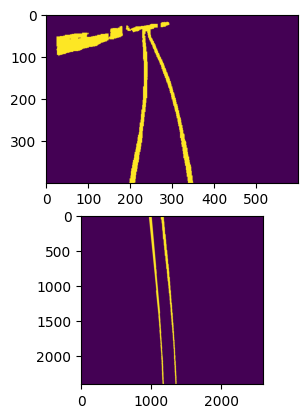

In [ ]:
def load_warp(mask_path):
    mask = np.load(mask_path)
    mask = mask[320:, x_c-300:x_c+300] # так обрезалось при расчете трапеции
    res = cv2.warpPerspective(np.array(mask), pmatrix_new, (2600, 2400))
    return res

fig, ax = plt.subplots(2, 1)

mask_pr = load_warp(msk_fs[25])

ax[1].imshow(mask_pr)

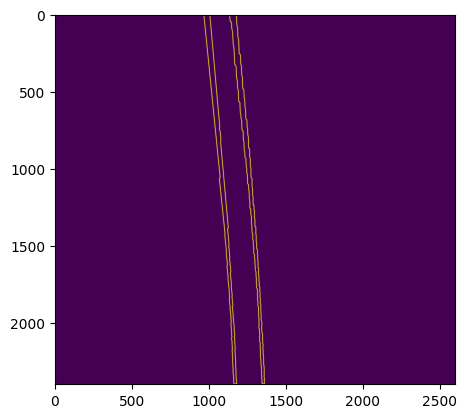

In [471]:
mask_cont = np.zeros_like(mask_pr)
contours, _ = cv2.findContours(mask_pr, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
cv2.drawContours(mask_cont, contours, -1, 1, 3)

plt.imshow(mask_cont)

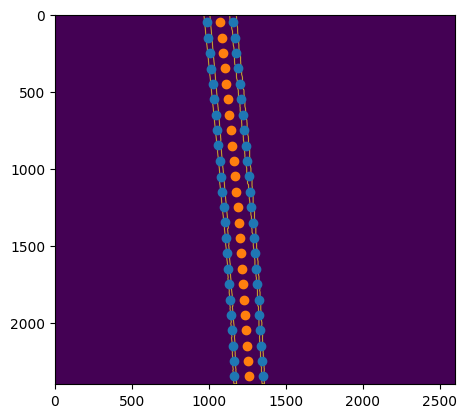

In [473]:
# картинку брал по частям гориз срезами, считал  центр масс контуров

centroids = []
st = 0
step = 100
for en in range(step, mask_cont.shape[1], step):

    contours, _ = cv2.findContours(mask_pr[st:en, :], cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    for contour in contours:
        M = cv2.moments(contour)
        if M["m00"] != 0:  # Проверяем, чтобы избежать деления на ноль
            cx = int(M["m10"] / M["m00"])
            cy = int(M["m01"] / M["m00"])
            centroids.append((cx, cy+st))

    st += step

X = np.array(centroids)[:, 0]
Y = np.array(centroids)[:, 1]

diff = np.diff(Y)

# средние точки между центрами масс кусков контуров
mid_p = []
for i, v in enumerate(diff):
    if v < 3:
        mid_p.append([X[i] - int((X[i] - X[i+1]) / 2), Y[i]])
mid_p = np.array(mid_p)

plt.imshow(mask_cont)
plt.scatter(X, Y)
plt.scatter(mid_p[:, 0], mid_p[:, 1]);


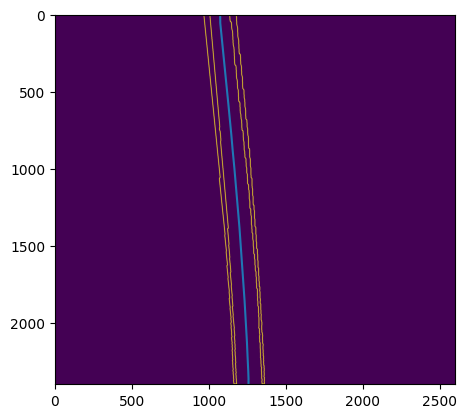

In [478]:
# Интеролировать серединки

y_centr = np.arange(mask_cont.shape[0])
x_centr = np.interp(y_centr, mid_p[:, 1], mid_p[:, 0])
plt.imshow(mask_cont)
plt.plot(x_centr, y_centr);

In [ ]:
# mask_cont = Image.fromarray(mask_cont)
# mask_cont.save('mask_cont.jpg')

In [398]:
# 25 # 16054.942 основ
# 24 # 16053.3 след
# ...

# 8.8мм в однм пикселе

# если идти вперед, отступ в пикселях на центр линии
def pix_step(ind1, ind2):
    return abs(int((round(coord[ind1] - coord[ind2], 2) * 1000) / 8.8))

print(pix_step(24, 25))
print(pix_step(23, 24))


181
181


In [ ]:
# открывается следующая картинка, выравнивается, вырезается ее часть до след координаты
# и вставляется в основное, совмещая центры
# взять нижнюю точку между рельсами на след картинке и учитывая координаты (у) поставить ее на центральной линии.

mask_nxt = load_warp(msk_fs[24])
mask_nxt_p = mask_nxt[-181: -1, :]
mask_nxt_p.shape

(180, 2600)

1255


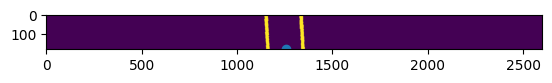

In [491]:
# простой вариант на попробовать

x_min = np.where(mask_nxt[-2, :] == 1)[0][0]
x_max = np.where(mask_nxt[-2, :] == 1)[0][-1]

m_p = x_min + ((x_max - x_min) // 2)

plt.imshow(mask_nxt_p)
plt.scatter(m_p, mask_nxt_p.shape[0]-1)
print(m_p)

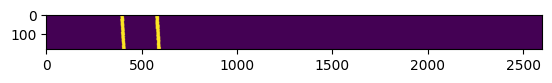

In [ ]:
# тест сопоставления
mask_test = np.zeros_like(mask_nxt_p)
t_p = 500
bord = 200

mask_test[:, t_p:t_p+bord] = mask_nxt_p[:, m_p:m_p+bord]  # справа от точки
mask_test[:, t_p-bord:t_p] = mask_nxt_p[:, m_p-bord:m_p]  # справа от точки

plt.imshow(mask_test)

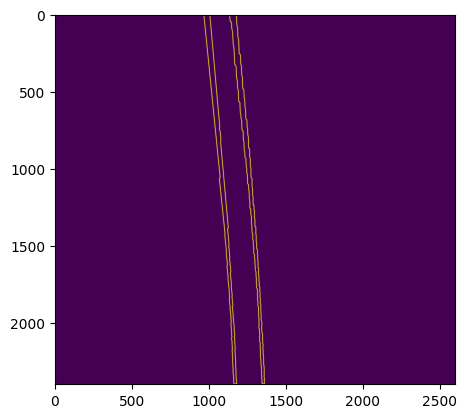

In [479]:
mask_res = mask_cont.copy()



plt.imshow(mask_res)